# Pupil-Behavior-Ephys examples

## Purpose
This notebook shows examples of relationship between pupil dilation dynamics and neural activity during the dynamic foraging task. 

## Manuscript figure panels
Generates figures showing:
- Cross-correlation functions between pupil dilation and neural activity
- Temporal decay characteristics of pupil-spike coupling
- Relationships between pupil features and behavioral encoding
- Comparisons with waveform features and task response properties

## Prerequisites
- Preprocessed pupil data from individual sessions
- Unit quality metrics and behavioral regression results
- Waveform features and basic ephys characterization
- Session-level behavioral performance metrics

In [84]:
# %%
import os
import sys
# Resolve code/beh_ephys_analysis (the folder containing `utils`) relative to this
# file's location, so imports work no matter where the repo is checked out.
import pathlib

# Resolve code/beh_ephys_analysis (the folder containing `utils`) relative to this
# file's location, so imports work no matter where the repo is checked out.
try:
    _here = pathlib.Path(__file__).resolve().parent          # script mode
except NameError:
    try:
        _here = pathlib.Path(__vsc_ipynb_file__).resolve().parent  # VS Code notebook
    except NameError:
        _here = pathlib.Path(os.getcwd())                    # other Jupyter fallback

_beh_ephys_root = str((_here / '../..').resolve())
if _beh_ephys_root not in sys.path:
    sys.path.insert(0, _beh_ephys_root)
import pandas as pd
import numpy as np
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as patches
import json
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import re
from utils.beh_functions import parseSessionID, session_dirs, get_unit_tbl, get_session_tbl, makeSessionDF
from utils.ephys_functions import plot_rate, correlate_nan_bi, correlate_nan, load_drift, get_spike_matrix
from utils.lick_utils import load_licks
from utils.photometry_utils import bin_timeseries_around_align
from utils.pupil_utils import load_pupil
from utils.combine_tools import apply_qc, to_str_intlike
from utils.plot_utils import combine_pdf_big
from utils.capsule_migration import capsule_directories
from aind_ephys_utils import align
from matplotlib.colors import LinearSegmentedColormap
from matplotlib import colormaps
import pickle
import shutil
import datetime
import seaborn as sns
from trimesh import load_mesh
from aind_dynamic_foraging_data_utils.nwb_utils import load_nwb_from_filename
import numbers
from scipy.interpolate import interp1d
from scipy.stats import pearsonr
from scipy.stats import zscore
%matplotlib widget
capsule_dirs = capsule_directories()
from utils.capsule_migration import CAPSULE_ROOT
from utils.panel_utils import save_panels, save_panel_csv, columns_to_df, heatmap_to_df
from ani_session_processing.pupil_analysis import pupil_analysis_session, plot_unit_pupil_correlation

In [58]:
capsule_dirs = capsule_directories()
target_folder = os.path.join(capsule_dirs['manuscript_fig_dir'], 'F_pupil_examples')
if not os.path.exists(target_folder):
    os.makedirs(target_folder)

In [51]:
examples = [('behavior_ZS061_2021-03-31_17-15-48', 'TT1_SS_01', ['FigureS16g_left', 'FigureS16i', 'FigureS16k', 'FigureS16m', 'FigureS16c'])]
# FigureS16g cross-crorrelation between pupil and spikes 
# FigureS16i Bl correlation
# FigureS16k Pupil psth by baseline spike rate
# FigureS16m Pupil dilation by response firing rate
# FigureS16c autocorrelation of pupil

Loading pupil file: mZS061d20210331_pupil.mat


/root/capsule/code/beh_ephys_analysis/ani_session_processing/pupil_analysis.py:610: RuntimeWarning: All-NaN slice encountered
  np.nanmax(pupil_values[mask]) - pupil_baseline[trial_ind]


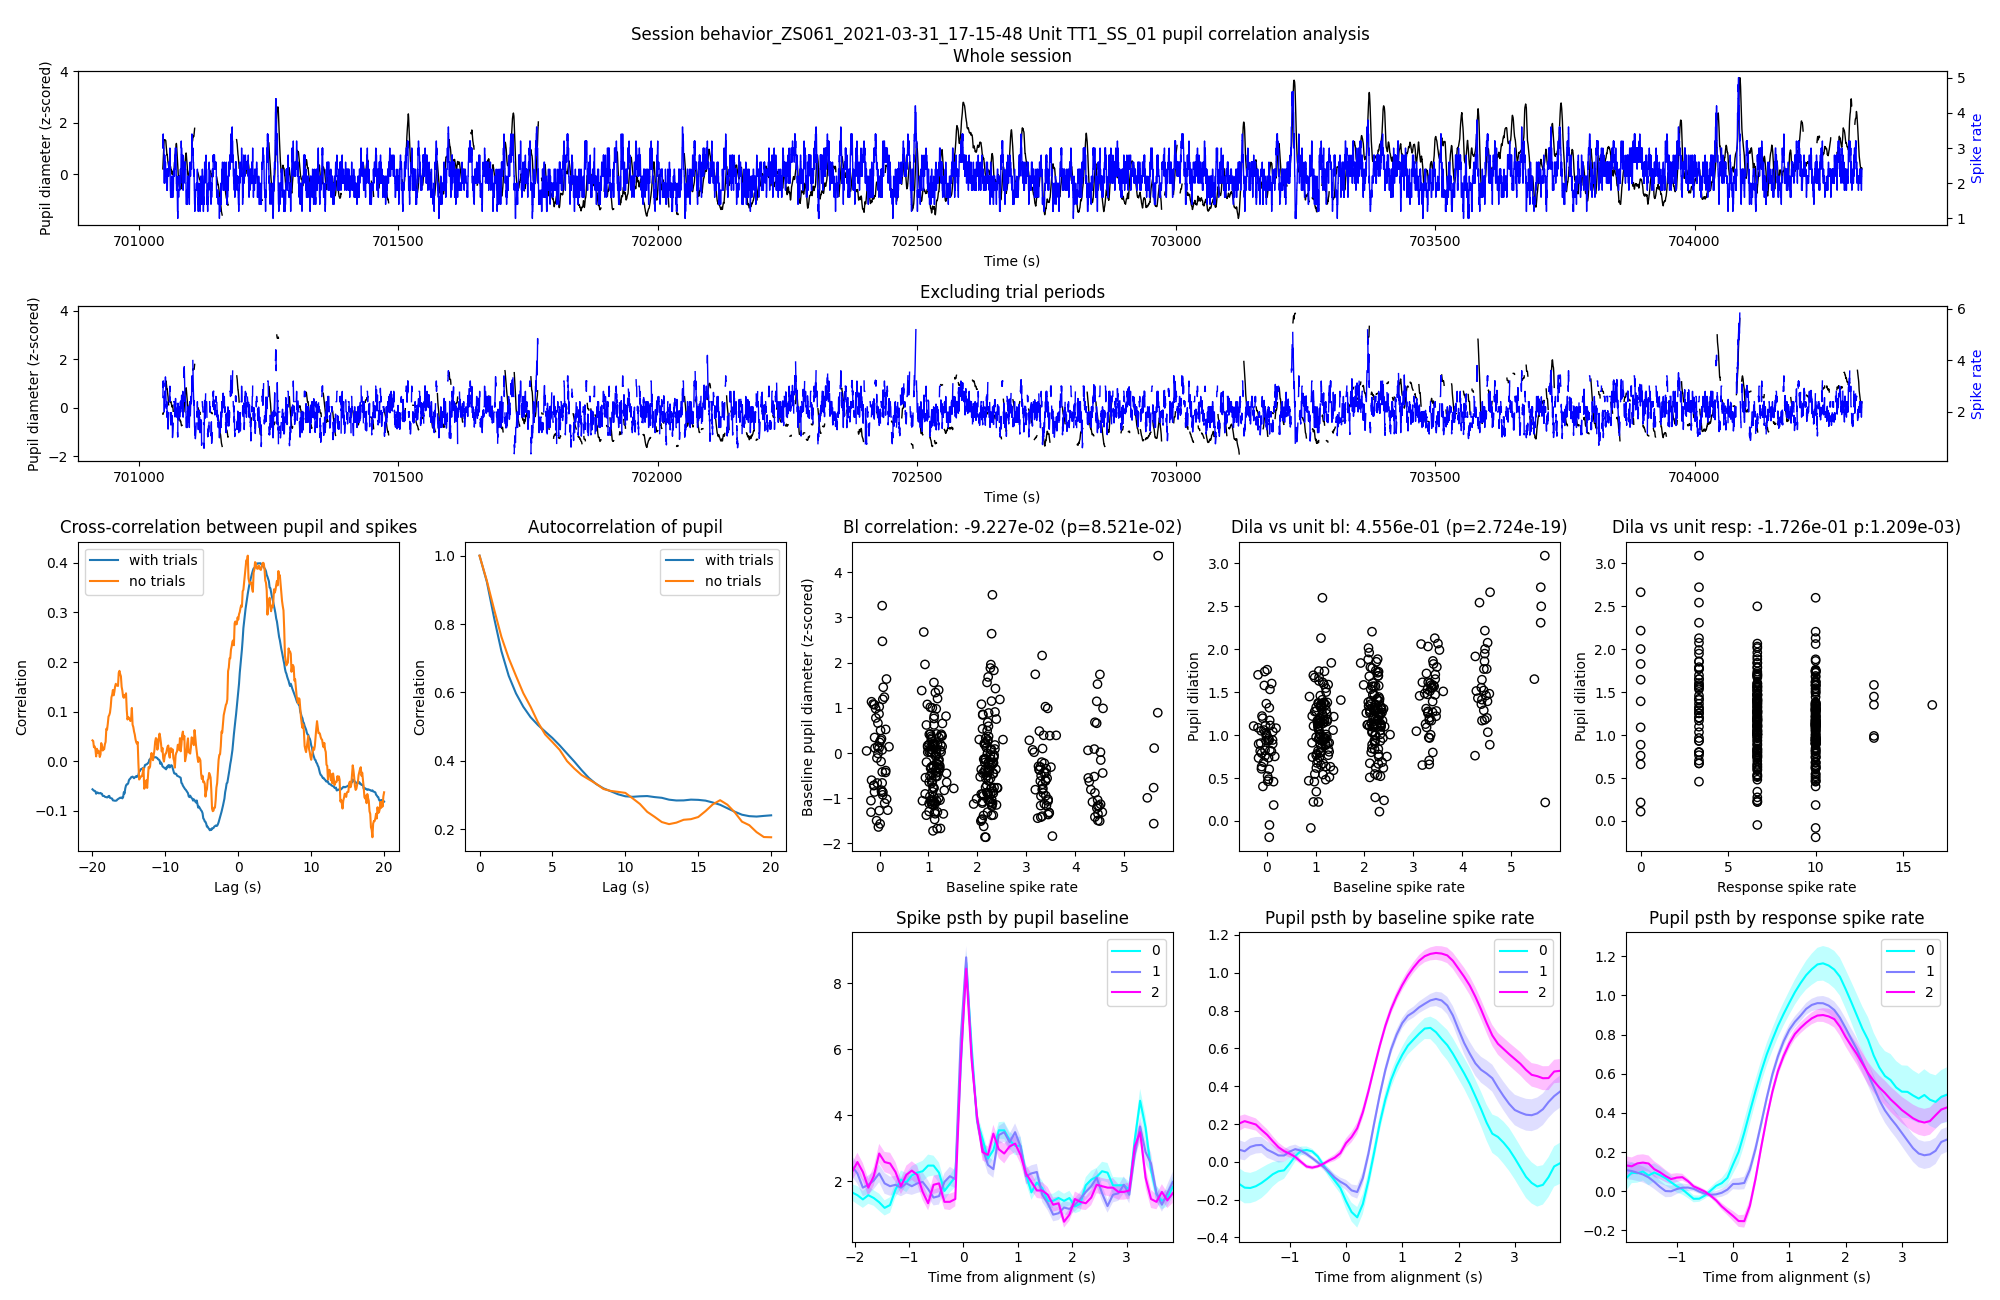

In [52]:
results = plot_unit_pupil_correlation(examples[0][0], units = [examples[0][1], ], win_length=20)

In [53]:
save_panels(results[1][0], target_folder, f'example_pupil_unit_analyais_{examples[0][0]}_{examples[0][1]}', examples[0][2], exts=("pdf", ))

['/root/capsule/scratch/results/manuscript/figures/F_pupil_examples/FigureS16g_left_example_pupil_unit_analyais_behavior_ZS061_2021-03-31_17-15-48_TT1_SS_01.pdf',
 '/root/capsule/scratch/results/manuscript/figures/F_pupil_examples/FigureS16i_example_pupil_unit_analyais_behavior_ZS061_2021-03-31_17-15-48_TT1_SS_01.pdf',
 '/root/capsule/scratch/results/manuscript/figures/F_pupil_examples/FigureS16k_example_pupil_unit_analyais_behavior_ZS061_2021-03-31_17-15-48_TT1_SS_01.pdf',
 '/root/capsule/scratch/results/manuscript/figures/F_pupil_examples/FigureS16m_example_pupil_unit_analyais_behavior_ZS061_2021-03-31_17-15-48_TT1_SS_01.pdf',
 '/root/capsule/scratch/results/manuscript/figures/F_pupil_examples/FigureS16c_example_pupil_unit_analyais_behavior_ZS061_2021-03-31_17-15-48_TT1_SS_01.pdf']

In [54]:
# Build panel CSVs from the same data plot_unit_pupil_correlation produces.
# CSV titles = the subplot titles in the corresponding manuscript panel.
#   FigureS16c  → "Autocorrelation of pupil"
#   FigureS16g  → "Cross-correlation between pupil and spikes"
#   FigureS16i  → "Bl correlation"
#   FigureS16k  → "Pupil psth by baseline spike rate"
#   FigureS16m  → "Pupil dilation by response firing rate"
#
# Recomputes the missing per-trial arrays / PSTH matrix here (mirrors the function
# internals, so no changes to pupil_analysis.py are required).

from utils.pupil_utils import load_pupil
from utils.ephys_functions import load_drift
from utils.photometry_utils import bin_timeseries_around_align
from aind_ephys_utils import align

_results_df, _figs = results
_session_id, _unit_id, _panel_letters = examples[0]

# --- rebuild session context ---
_session_dir = session_dirs(session_id=_session_id)
_unit_tbl = get_unit_tbl(_session_id, data_type='curated')
_spike_times = _unit_tbl.loc[_unit_tbl['unit_id'] == _unit_id, 'spike_times'].values[0]
_session_df_full = get_session_tbl(_session_id)

_pupil = load_pupil(_session_id)
_pupil_times = _pupil['pupil_times']
_pupil_values = _pupil['pupil_diameter_z'].copy()

_time_conf_threshold, _dia_conf_threshold = 0.9, 0.95
_qual_mask_all = (_pupil['time_conf_trial'] > _time_conf_threshold) & (_pupil['dia_conf_trial'] > _dia_conf_threshold)
for _ti, _gc in enumerate(_session_df_full['goCue_start_time'].values):
    if not _qual_mask_all[_ti]:
        _pupil_values[(_pupil_times >= _gc - 3) & (_pupil_times <= _gc + 3)] = np.nan

with open(os.path.join(_session_dir['processed_dir'], f'{_session_id}_qm.json')) as _f:
    _qm = json.load(_f)
_rec_start, _rec_end = _qm['ephys_cut'][0], _qm['ephys_cut'][1]
_drift = load_drift(_session_id, _unit_id, 'curated')
_start_unit, _end_unit = _rec_start, _rec_end
_session_tbl_curr = _session_df_full.copy()
if _drift is not None:
    if _drift['ephys_cut'][0] is not None:
        _start_unit = max(_start_unit, _drift['ephys_cut'][0])
        _session_tbl_curr = _session_tbl_curr[_session_tbl_curr['goCue_start_time'] >= _drift['ephys_cut'][0]]
    if _drift['ephys_cut'][1] is not None:
        _end_unit = min(_end_unit, _drift['ephys_cut'][1])
        _session_tbl_curr = _session_tbl_curr[_session_tbl_curr['goCue_start_time'] <= _drift['ephys_cut'][1]]

# per-trial baseline spike rate (1 s pre-goCue) and pupil baseline (same window)
_align_times = _session_tbl_curr['goCue_start_time'].values
_time_bins, _baseline_mat, _ = align.align_to_events(_spike_times, _align_times, (-1, -0.01), bin_size=0.9)
_baseline = _baseline_mat[0, :] / 0.9
_pupil_baseline, _ = bin_timeseries_around_align(
    {'time': _pupil_times, 'value': _pupil_values},
    _align_times, step_size=0.9, bin_size=0.9, t_start=-1, t_stop=0)
_pupil_baseline = _pupil_baseline.flatten()

# per-trial pupil dilation (max in 0-2 s window − baseline)
_dilation = []
for _ti, _gc in enumerate(_align_times):
    _m = (_pupil_times >= _gc) & (_pupil_times <= _gc + 2)
    if np.any(_m):
        _dilation.append(np.nanmax(_pupil_values[_m]) - _pupil_baseline[_ti])
    else:
        _dilation.append(np.nan)
_dilation = np.array(_dilation)

# per-trial response spike rate (0-0.3 s post-goCue)
_response_spike_rate = np.array([
    np.sum((_spike_times >= _gc) & (_spike_times <= _gc + 0.3)) / 0.3
    for _gc in _align_times
])

# Pupil PSTH (trials × time), dilation = pupil − baseline
_pupil_mat, _slide_times = bin_timeseries_around_align(
    {'time': _pupil_times, 'value': _pupil_values},
    _align_times, step_size=0.1, bin_size=0.2, t_start=-2, t_stop=4,
)
_pupil_mat_dilation = _pupil_mat - _pupil_baseline[:, np.newaxis]

# --- existing arrays already on the results row ---
_row = _results_df.iloc[0]

_base_name = f'pupil_unit_{_session_id}_{_unit_id}'

# FigureS16c — Autocorrelation of pupil
save_panel_csv(
    columns_to_df(
        lag_s=np.asarray(_row['auto_corr_pupil_lags']),
        autocorr_with_trials=np.asarray(_row['auto_corr_pupil_with_trials']),
        autocorr_no_trials=np.asarray(_row['auto_corr_pupil_no_trials']),
    ),
    target_folder, _base_name, ['FigureS16c'], plot_type='Autocorrelation of pupil',
)

# FigureS16g — Cross-correlation between pupil and spikes
save_panel_csv(
    columns_to_df(
        lag_s=np.asarray(_row['crosscorr_lags']),
        crosscorr_with_trials=np.asarray(_row['crosscorr_with_trials']),
        crosscorr_no_trials=np.asarray(_row['crosscorr_no_trials']),
    ),
    target_folder, _base_name, ['FigureS16g'], plot_type='Cross-correlation between pupil and spikes',
)

# FigureS16i — Bl correlation (per-trial baseline spike rate vs baseline pupil)
save_panel_csv(
    columns_to_df(
        trial_index=np.arange(len(_baseline)),
        baseline_spike_rate=_baseline,
        pupil_baseline=_pupil_baseline,
    ),
    target_folder, _base_name, ['FigureS16i'], plot_type='Bl correlation',
)

# FigureS16k — Pupil psth by baseline spike rate: mean±SEM per baseline tertile
_n_bins = 3
_bl_ok = ~np.isnan(_baseline)
_bl_edges = np.percentile(_baseline[_bl_ok], np.linspace(0, 100, _n_bins + 1))
_bl_edges[0] -= 1e-6; _bl_edges[-1] += 1e-6
_bl_bin = np.digitize(_baseline, _bl_edges[1:-1])  # 0..n_bins-1
_k_cols = {'time_s': _slide_times}
for _b in range(_n_bins):
    _sel = np.where(_bl_bin == _b)[0]
    if len(_sel):
        _M = _pupil_mat_dilation[_sel, :]
        _k_cols[f'baseline_tertile{_b}_mean'] = np.nanmean(_M, axis=0)
        _k_cols[f'baseline_tertile{_b}_sem'] = np.nanstd(_M, axis=0) / np.sqrt(np.sum(~np.isnan(_M), axis=0))
save_panel_csv(columns_to_df(**_k_cols), target_folder, _base_name, ['FigureS16k'], plot_type='Pupil psth by baseline spike rate')

# FigureS16m — Pupil dilation by response firing rate (scatter)
save_panel_csv(
    columns_to_df(
        trial_index=np.arange(len(_response_spike_rate)),
        response_spike_rate=_response_spike_rate,
        pupil_dilation=_dilation,
    ),
    target_folder, _base_name, ['FigureS16m'], plot_type='Pupil dilation by response firing rate',
)

Loading pupil file: mZS061d20210331_pupil.mat


/tmp/ipykernel_303530/3671329709.py:64: RuntimeWarning: All-NaN slice encountered
  _dilation.append(np.nanmax(_pupil_values[_m]) - _pupil_baseline[_ti])


['/root/capsule/scratch/results/manuscript/figures/F_pupil_examples/FigureS16m_pupil_unit_behavior_ZS061_2021-03-31_17-15-48_TT1_SS_01_Pupil_dilation_by_response_firing_rate.csv']

Loading pupil file: mZS060d20210403_pupil.mat
Loading pupil file: mZS060d20210403_pupil.mat
FigureS16e_bottom_left (behavior_ZS060_2021-04-03_17-45-00, stay vs switch) → CSV saved
Loading pupil file: mZS060d20210403_pupil.mat
FigureS16e_bottom_right (behavior_ZS060_2021-04-03_17-45-00, reward vs no reward) → CSV saved
Loading pupil file: mZS062d20210330_pupil.mat
Loading pupil file: mZS062d20210330_pupil.mat
FigureS16e_top_left (behavior_ZS062_2021-03-30_18-30-24, stay vs switch) → CSV saved
Loading pupil file: mZS062d20210330_pupil.mat
FigureS16e_top_right (behavior_ZS062_2021-03-30_18-30-24, reward vs no reward) → CSV saved


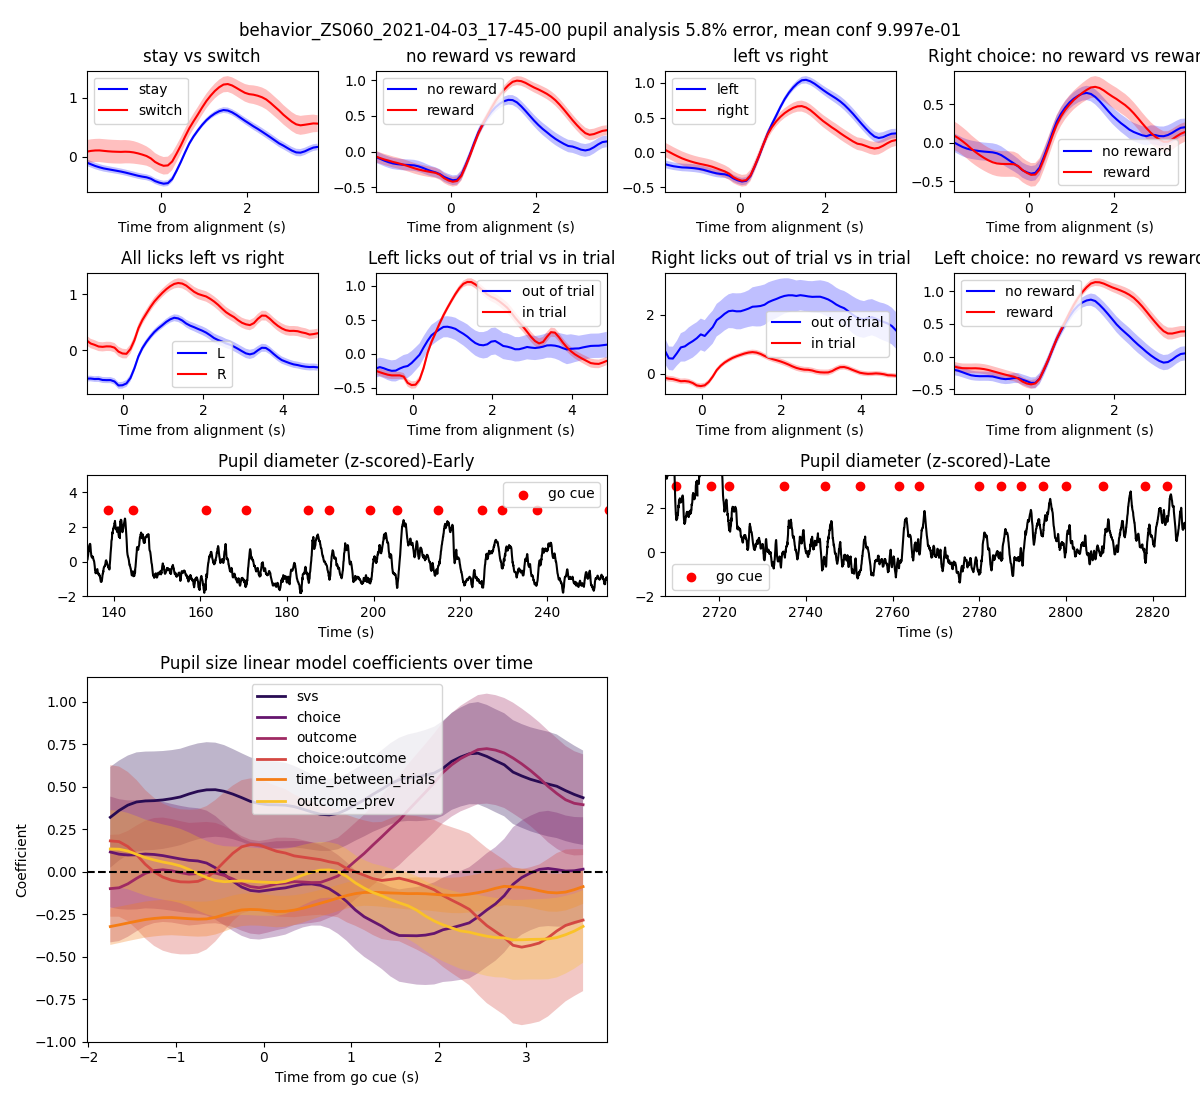

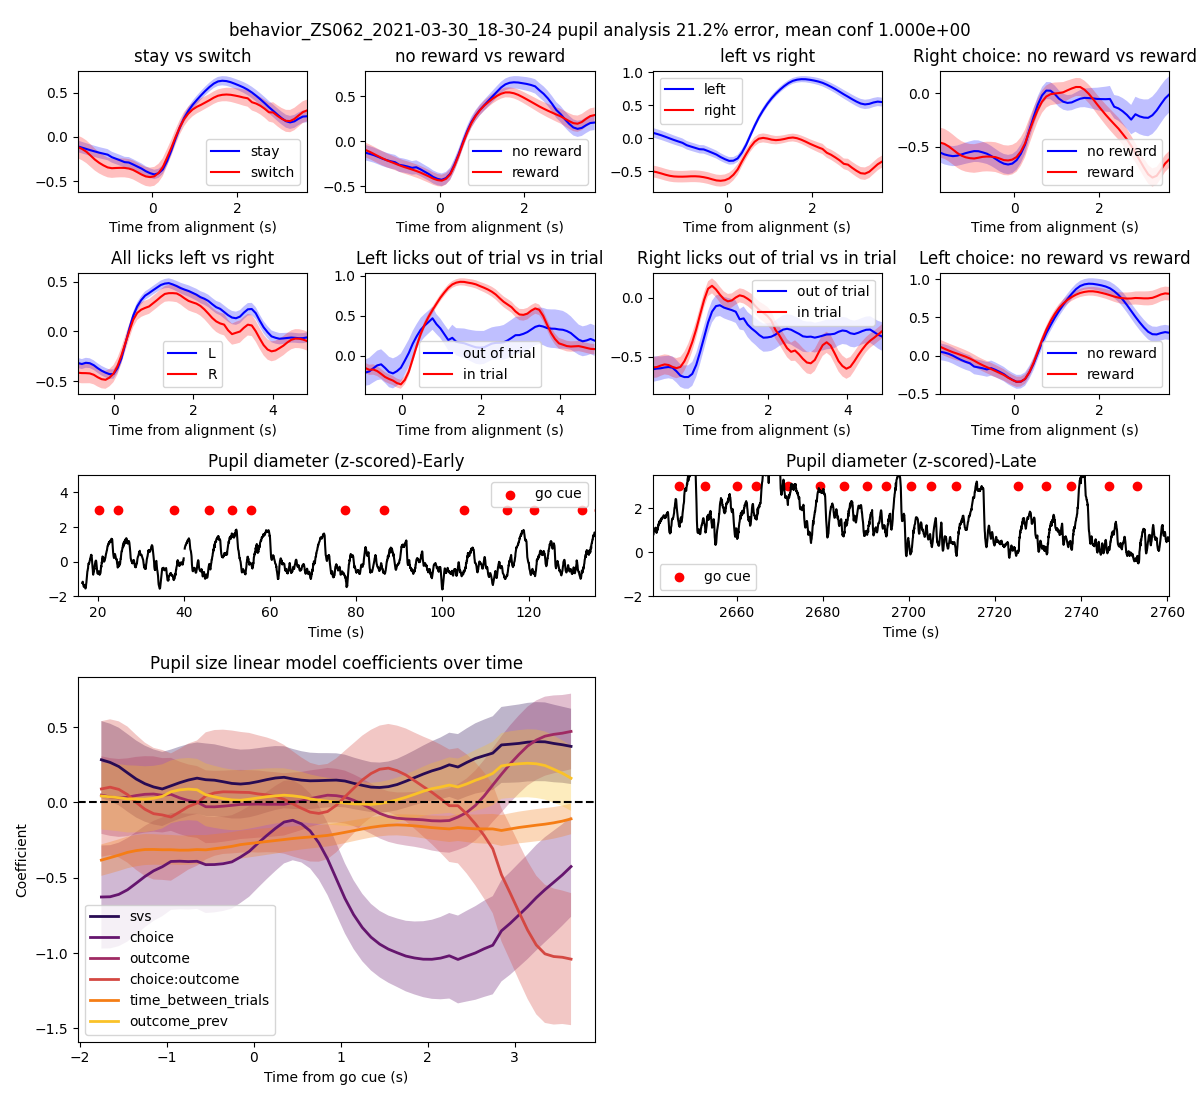

In [55]:
examples = [('behavior_ZS060_2021-04-03_17-45-00', ['FigureS16e_bottom_left', 'FigureS16e_bottom_right']),
            ('behavior_ZS062_2021-03-30_18-30-24', ['FigureS16e_top_left', 'FigureS16e_top_right'])]

# Panel ID → subplot title
#   FigureS16e_bottom_left  : stay vs switch psth
#   FigureS16e_bottom_right : reward vs no reward psth
#   FigureS16e_top_left     : stay vs switch psth
#   FigureS16e_top_right    : reward vs no reward psth
panel_titles = {
    'FigureS16e_bottom_left':  'stay vs switch',
    'FigureS16e_bottom_right': 'reward vs no reward',
    'FigureS16e_top_left':     'stay vs switch',
    'FigureS16e_top_right':    'reward vs no reward',
}

CONTRASTS = {
    'stay vs switch':      {'column': 'svs',     'group0': 'stay',      'group1': 'switch'},
    'reward vs no reward': {'column': 'outcome', 'group0': 'no reward', 'group1': 'reward'},
}


def compute_pupil_psth(session, contrast, bin_size=0.15, step_size=0.1,
                       t_start=-1, t_stop=5, time_conf_threshold=0.9,
                       dia_conf_threshold=0.95):
    """Mirror pupil_analysis_session's PSTH block for one contrast."""
    beh_df = get_session_tbl(session)
    session_df = makeSessionDF(session)
    pupil_data = load_pupil(session)
    if pupil_data is None:
        raise RuntimeError(f'No pupil data for {session}')

    qual_mask_all = (
        (pupil_data['time_conf_trial'] > time_conf_threshold)
        & (pupil_data['dia_conf_trial'] > dia_conf_threshold)
    )
    qual_mask_choice = qual_mask_all[beh_df['animal_response'].values != 2]

    align_times = session_df['go_cue_time'].values[qual_mask_choice]
    out, time_bins = bin_timeseries_around_align(
        ts={'time': pupil_data['pupil_times'], 'value': pupil_data['pupil_diameter_z']},
        align_times=align_times,
        step_size=step_size,
        bin_size=bin_size,
        t_start=t_start,
        t_stop=t_stop,
    )

    spec = CONTRASTS[contrast]
    values = session_df[spec['column']].values[qual_mask_choice]
    m0 = values == 0
    m1 = values == 1

    def _stats(mat):
        return (
            np.nanmean(mat, axis=0),
            np.nanstd(mat, axis=0) / np.sqrt(np.sum(~np.isnan(mat), axis=0)),
        )

    mean0, sem0 = _stats(out[m0, :])
    mean1, sem1 = _stats(out[m1, :])
    return time_bins, mean0, sem0, mean1, sem1, spec['group0'], spec['group1']


for session_id, panels in examples:
    # figure + save
    _, _, fig = pupil_analysis_session(session_id)
    save_panels(fig, target_folder, f'pupil_analysis_{session_id}', panels, exts=('pdf',))

    # per-panel CSVs — each named after the panel's subplot title
    for panel in panels:
        title = panel_titles[panel]
        time_bins, mean0, sem0, mean1, sem1, g0, g1 = compute_pupil_psth(session_id, title)
        cols = {
            'time_s': time_bins,
            f'{g0}_mean': mean0,
            f'{g0}_sem': sem0,
            f'{g1}_mean': mean1,
            f'{g1}_sem': sem1,
        }
        save_panel_csv(
            columns_to_df(**cols),
            target_folder,
            f'pupil_psth_{session_id}',
            [panel],
            plot_type=title,
        )
        print(f'{panel} ({session_id}, {title}) → CSV saved')


# Raw trace

In [74]:
session = 'behavior_ZS062_2021-05-06_15-46-14'
unit = 'TT6_SS_01'
panel = 'FigureS16b'

Loading pupil file: mZS062d20210506_pupil.mat


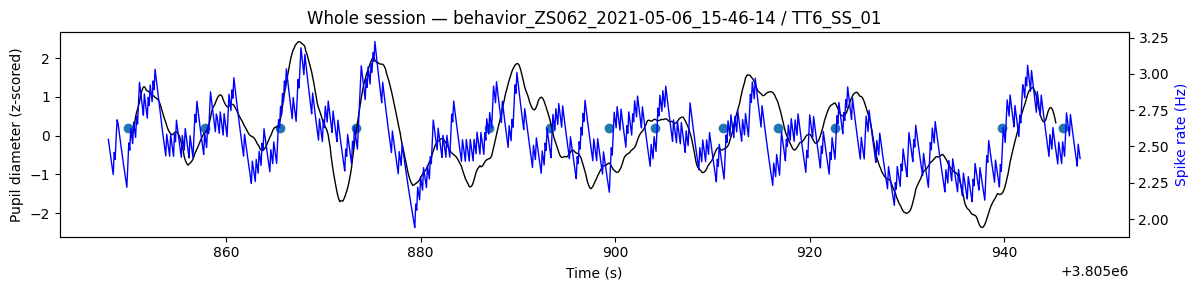

['/root/capsule/scratch/results/manuscript/figures/F_pupil_examples/FigureS16b_raw_trace_behavior_ZS062_2021-05-06_15-46-14_TT6_SS_01_goCue_start_time.csv']

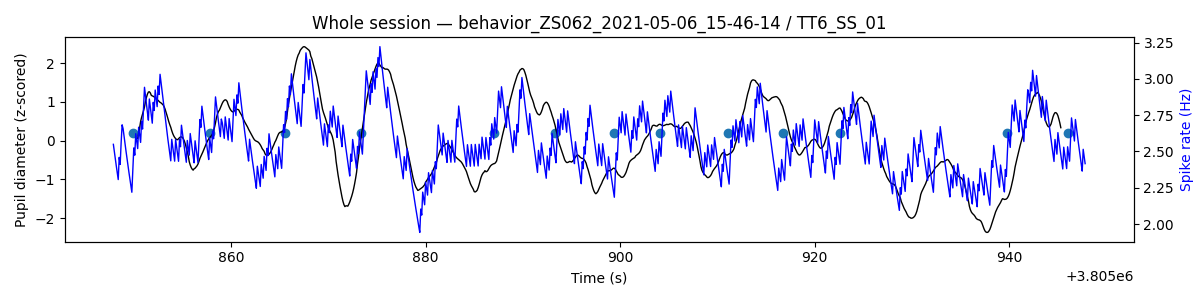

In [86]:
# Whole-session raw trace: smoothed spike rate + z-scored pupil diameter.
# Spike rate: get_spike_matrix(kernel=True, tau_decay=0.02) — PSP-filter smoothing.
# Pupil: pupil_diameter_z, blanked to NaN within ±3 s of trials failing time/dia QC,
# then averaged in sliding (bin_size, step_size) windows aligned to start_unit.
step_size = 0.1
tau_decay = 5
tau_rise = 0.001
pupil_bin_size = 5.0
time_conf_threshold = 0.9
dia_conf_threshold = 0.95

_session_dir = session_dirs(session_id=session)
_unit_tbl = get_unit_tbl(session, data_type='curated')
_spike_times = _unit_tbl.loc[_unit_tbl['unit_id'] == unit, 'spike_times'].values[0]
_session_df = get_session_tbl(session)

_pupil = load_pupil(session)
_pupil_times = _pupil['pupil_times']
_pupil_values = _pupil['pupil_diameter_z'].copy()

# blank out ±3 s around trials that fail the confidence QC
_qual = (_pupil['time_conf_trial'] > time_conf_threshold) & (_pupil['dia_conf_trial'] > dia_conf_threshold)
for _ti, _gc in enumerate(_session_df['goCue_start_time'].values):
    if not _qual[_ti]:
        _pupil_values[(_pupil_times >= _gc - 3) & (_pupil_times <= _gc + 3)] = np.nan

# window bounds: session QM ∩ per-unit drift cut
with open(os.path.join(_session_dir['processed_dir'], f'{session}_qm.json')) as _f:
    _qm = json.load(_f)
_start_unit = _session_df['goCue_start_time'].values[12] - 2
_end_unit   = _start_unit + 100


# smoothed spike rate via PSP kernel (single alignment at _start_unit, spans 0 → end-start)
_spike_mat, _spike_bins = get_spike_matrix(
    _spike_times,
    np.array([_start_unit]),
    pre_event=0,
    post_event=_end_unit - _start_unit,
    stepSize=step_size,
    kernel=True,
    tau_rise=tau_rise,
    tau_decay=tau_decay,
)
_spike_rate = _spike_mat[0, :]
_spike_time_axis = _spike_bins + _start_unit

# pupil binned on a comparable time grid
_pupil_binned, _bin_centers = bin_timeseries_around_align(
    ts={'time': _pupil_times, 'value': _pupil_values},
    align_times=np.array([_start_unit]),
    step_size=step_size,
    bin_size=pupil_bin_size,
    t_start=0,
    t_stop=_end_unit - _start_unit,
)
_pupil_binned = _pupil_binned.flatten()
_pupil_time_axis = _bin_centers + _start_unit

trial_start_times = _session_df['goCue_start_time'].values
trial_start_times = trial_start_times[(trial_start_times > _start_unit) & (trial_start_times < _end_unit)]
# plot
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(_pupil_time_axis, zscore(_pupil_binned), color='black', linewidth=1, label='pupil (z)')
ax.scatter(trial_start_times, np.full(len(trial_start_times), 0.2))
ax.set_ylabel('Pupil diameter (z-scored)', color='black')
ax.set_xlabel('Time (s)')
ax.set_title(f'Whole session — {session} / {unit}')
# ax.scatter(_session_df['goCue_start_time'].values, np.full(len(_session_df), 0.2), 'k')
ax2 = ax.twinx()
ax2.plot(_spike_time_axis, _spike_rate, color='blue', linewidth=1, label='spike rate (PSP)')
ax2.set_ylabel('Spike rate (Hz)', color='blue')
plt.tight_layout()

# save figure panel
_name = f'raw_trace_{session}_{unit}'
save_panels(fig, target_folder, _name, [panel], exts=('pdf',))

# save time-rate-pupil csv
save_panel_csv(
    columns_to_df(
        time_s=_spike_time_axis,
        spike_rate_hz=_spike_rate,
        pupil_time_s=_pupil_time_axis,
        pupil_diameter_z=zscore(_pupil_binned),
    ),
    target_folder, _name, [panel],
)
display(fig)
##FigureS16b##
# save session trial start time
save_panel_csv(
    columns_to_df(
        time_s = trial_start_times 
    ),
    target_folder, _name + '_goCue_start_time', [panel]
)